# Preparation

## Import Library

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import warnings
warnings.filterwarnings("ignore",category=FutureWarning)

## Import Dataset

In [37]:
Df=pd.read_csv('/content/drive/MyDrive/Dataset/loan_data_2007_2014.csv')
Df.head()

/tmp/ipython-input-503/1551672002.py:1: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  Df=pd.read_csv('/content/drive/MyDrive/Dataset/loan_data_2007_2014.csv')


,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Data Understanding

In [4]:
Df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,215934.000000,62638.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466140.000000,98974.000000,466285.0,0.0,0.0,0.0,466256.000000,3.960090e+05,3.960090e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,34.104430,74.306012,11.187069,0.160564,1.623020e+04,56.176947,25.064430,4410.062342,4408.452258,11540.686220,11469.892747,8866.014657,2588.677225,0.650129,85.344211,8.961534,3123.913796,0.009085,42.852547,1.0,NaN,NaN,NaN,0.004002,1.919135e+02,1.388017e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,21.778487,30.357653,4.987526,0.510863,2.067625e+04,23.732628,11.600141,6355.078769,6353.198001,8265.627112,8254.157579,7031.687997,2483.809661,5.265730,552.216084,85.491437,5554.737393,0.108648,21.662591,0.0,NaN,NaN,NaN,0.068637,1.463021e+04,1.521147e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,16.000000,53.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,0.000000,5552.125349,5499.250000,3708.560000,957.280000,0.000000,0.000000,0.000000,312.620000,0.000000,26.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.861800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,31.000000,76.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.470000,441.380000,9419.250943,9355.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,545.960000,0.000000,42.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,8.153900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,49.000000,102.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,7338.390000,15308.158460,15231.310000,12000.000000,3304.530000,0.000000,0.000000,0.000000,3187.510000,0.000000,59.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.089530e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

In [5]:
Df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

In [38]:
Df.duplicated().sum()

np.int64(0)

In [6]:
Df.isna().sum()

,0
Unnamed: 0,0
id,0
member_id,0
loan_amnt,0
funded_amnt,0
funded_amnt_inv,0
term,0
int_rate,0
installment,0
grade,0


In [7]:
duplicate=Df.duplicated().sum()
print("Total duplicated data:",duplicate)

Total duplicated data: 0


In [8]:
row, column=Df.shape
print("Number of Row of Dataset:",row)
print("Number of Column of Dataset")

Number of Row of Dataset: 466285
Number of Column of Dataset


# Data Cleaning

## Drop Irrelevant Data

In [9]:
Df=Df.drop(Df[Df['loan_status']=='Current'].index)

In [10]:
Df['zip_code']=Df['zip_code'].str[:3]
Df['zip_code']=Df['zip_code'].astype(int)

## Feature Engineering

In [11]:
cols=['issue_d','last_pymnt_d','last_credit_pull_d','earliest_cr_line']
for col in cols:
  Df[col]=pd.to_datetime(Df[col], format='%b-%y')

In [12]:
Df['credit_history_months'] = (
    (Df['issue_d'] - Df['earliest_cr_line']) / pd.Timedelta(days=30)
).round()
Df['credit_history_years'] = Df['credit_history_months'] / 12
Df['issue_month']=Df['issue_d'].dt.year
Df['issue_year']=Df['issue_d'].dt.month

In [14]:
transform_loan={
    'Charged Off':'Bad',
    'Default':'Bad',
    'Late (31-120 days)':'Bad',
    'Late (16-30 days)':'Bad',
    'In Grace Period':'Bad',
    'Does not meet the credit policy. Status:Charged Off':'Bad',
    'Fully Paid':'Good',
    'Does not meet the credit policy. Status:Fully Paid':'Good'
}
Df['loan_status']=Df['loan_status'].map(transform_loan)

## Data Missing Handling

In [15]:
Df['emp_title']=Df['emp_title'].fillna('Unknown')
Df['emp_length']=Df['emp_length'].fillna('Unknown')
Df['annual_inc']=Df['annual_inc'].fillna(Df['annual_inc'].median())
Df['title']=Df['title'].fillna('Unknown')
Df['delinq_2yrs']=Df['delinq_2yrs'].fillna(0)
Df['inq_last_6mths']=Df['inq_last_6mths'].fillna(0)
Df['open_acc']=Df['open_acc'].fillna(Df['open_acc'].median())
Df['pub_rec']=Df['pub_rec'].fillna(0)
Df['revol_util']=Df['revol_util'].fillna(Df['revol_util'].median())
Df['total_acc']=Df['total_acc'].fillna(Df['total_acc'].median())
Df['total_rev_hi_lim']=Df['total_rev_hi_lim'].fillna(Df['total_rev_hi_lim'].median())
Df['tot_cur_bal']=Df['tot_cur_bal'].fillna(Df['tot_cur_bal'].median())
Df['acc_now_delinq']=Df['acc_now_delinq'].fillna(0)
Df['collections_12_mths_ex_med']=Df['collections_12_mths_ex_med'].fillna(0)
Df['last_credit_pull_d']=Df['last_credit_pull_d'].fillna('Jan-16')
Df['last_pymnt_amnt']=Df['last_pymnt_amnt'].fillna(Df['last_pymnt_amnt'].median())
Df['tot_coll_amt']=Df['tot_coll_amt'].fillna(Df['tot_coll_amt'].median())
Df['last_pymnt_d']=Df['last_pymnt_d'].fillna('Jan-16')
Df['credit_history_months']=Df['credit_history_months'].fillna(Df['credit_history_months'].median())
Df['credit_history_years']=Df['credit_history_years'].fillna(Df['credit_history_years'].median())

## Drop Irrelevant Column

In [16]:
Df = Df.drop(columns=[
    'desc','mths_since_last_delinq',
    'mths_since_last_record','Unnamed: 0',
    'id','member_id','mths_since_last_major_derog',
    'inq_last_12m','total_cu_tl','inq_fi',
    'all_util','max_bal_bc','open_rv_24m','open_rv_12m',
    'il_util','total_bal_il','mths_since_rcnt_il',
    'open_il_24m','open_il_12m','open_il_6m','open_acc_6m',
    'verification_status_joint','dti_joint',
    'annual_inc_joint','next_pymnt_d','url','grade',
    'issue_d','last_pymnt_d','last_credit_pull_d','earliest_cr_line','application_type'
], axis=1)

# EDA(Exploratory Data Analysis)

### Visualisasi Status Pinjaman

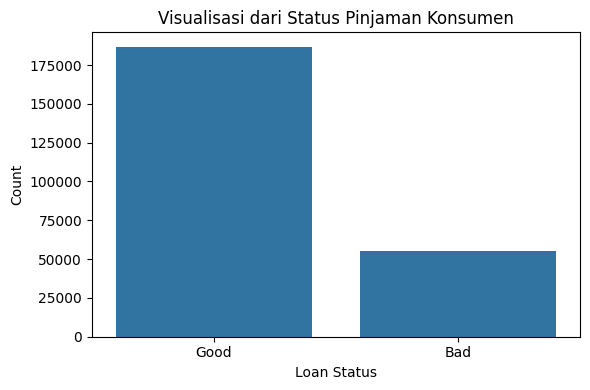

In [17]:
plt.figure(figsize=(6,4))
sns.countplot(data=Df, x='loan_status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Visualisasi dari Status Pinjaman Konsumen')
plt.tight_layout()
plt.show()

### Visualisasi dari Lama Pinjaman

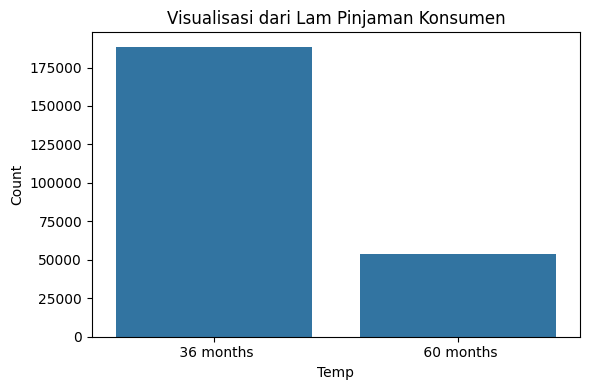

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(data=Df, x='term')
plt.xlabel('Temp')
plt.ylabel('Count')
plt.title('Visualisasi dari Lam Pinjaman Konsumen')
plt.tight_layout()
plt.show()

### Visualisasi dari Status pinjaman vs Status verifikasi pendapatan peminjam

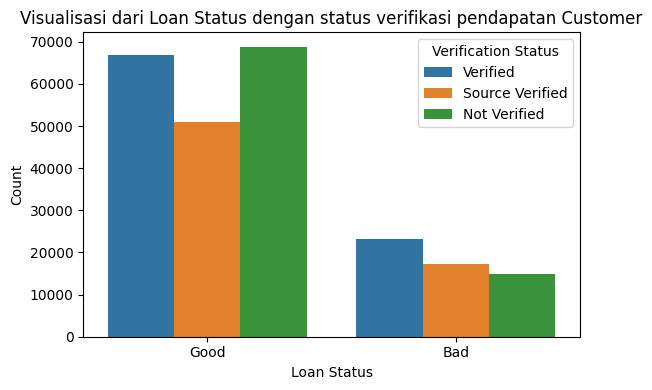

In [19]:
plt.figure(figsize=(6,4))
sns.countplot(data=Df, x='loan_status', hue='verification_status')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.legend(title='Verification Status')
plt.title('Visualisasi dari Loan Status dengan status verifikasi pendapatan Customer')
plt.tight_layout()
plt.show()

### Visualisasi dari Loan Status vs Data Peminjam

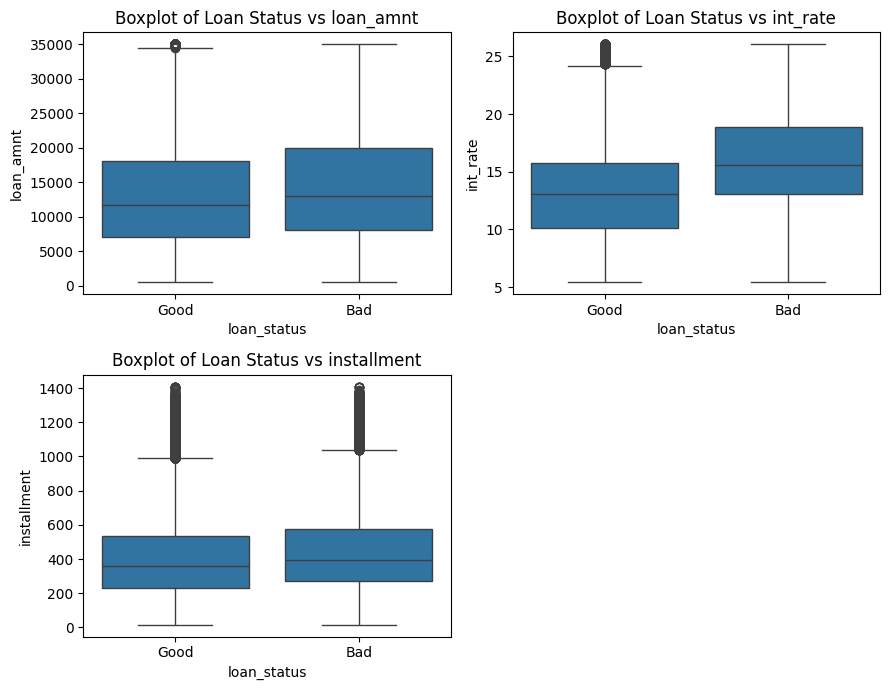

In [20]:
numeric_feature=['loan_amnt','int_rate','installment']
fig, axes=plt.subplots(2,2, figsize=(9,7))
axes=axes.flatten()
for i, col in enumerate(numeric_feature):
  sns.boxplot(data=Df, x='loan_status', y=col, ax=axes[i])
  axes[i].set_ylabel(col)
  axes[i].set_title(f'Boxplot of Loan Status vs {col}')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

### Identifikasi Outlier

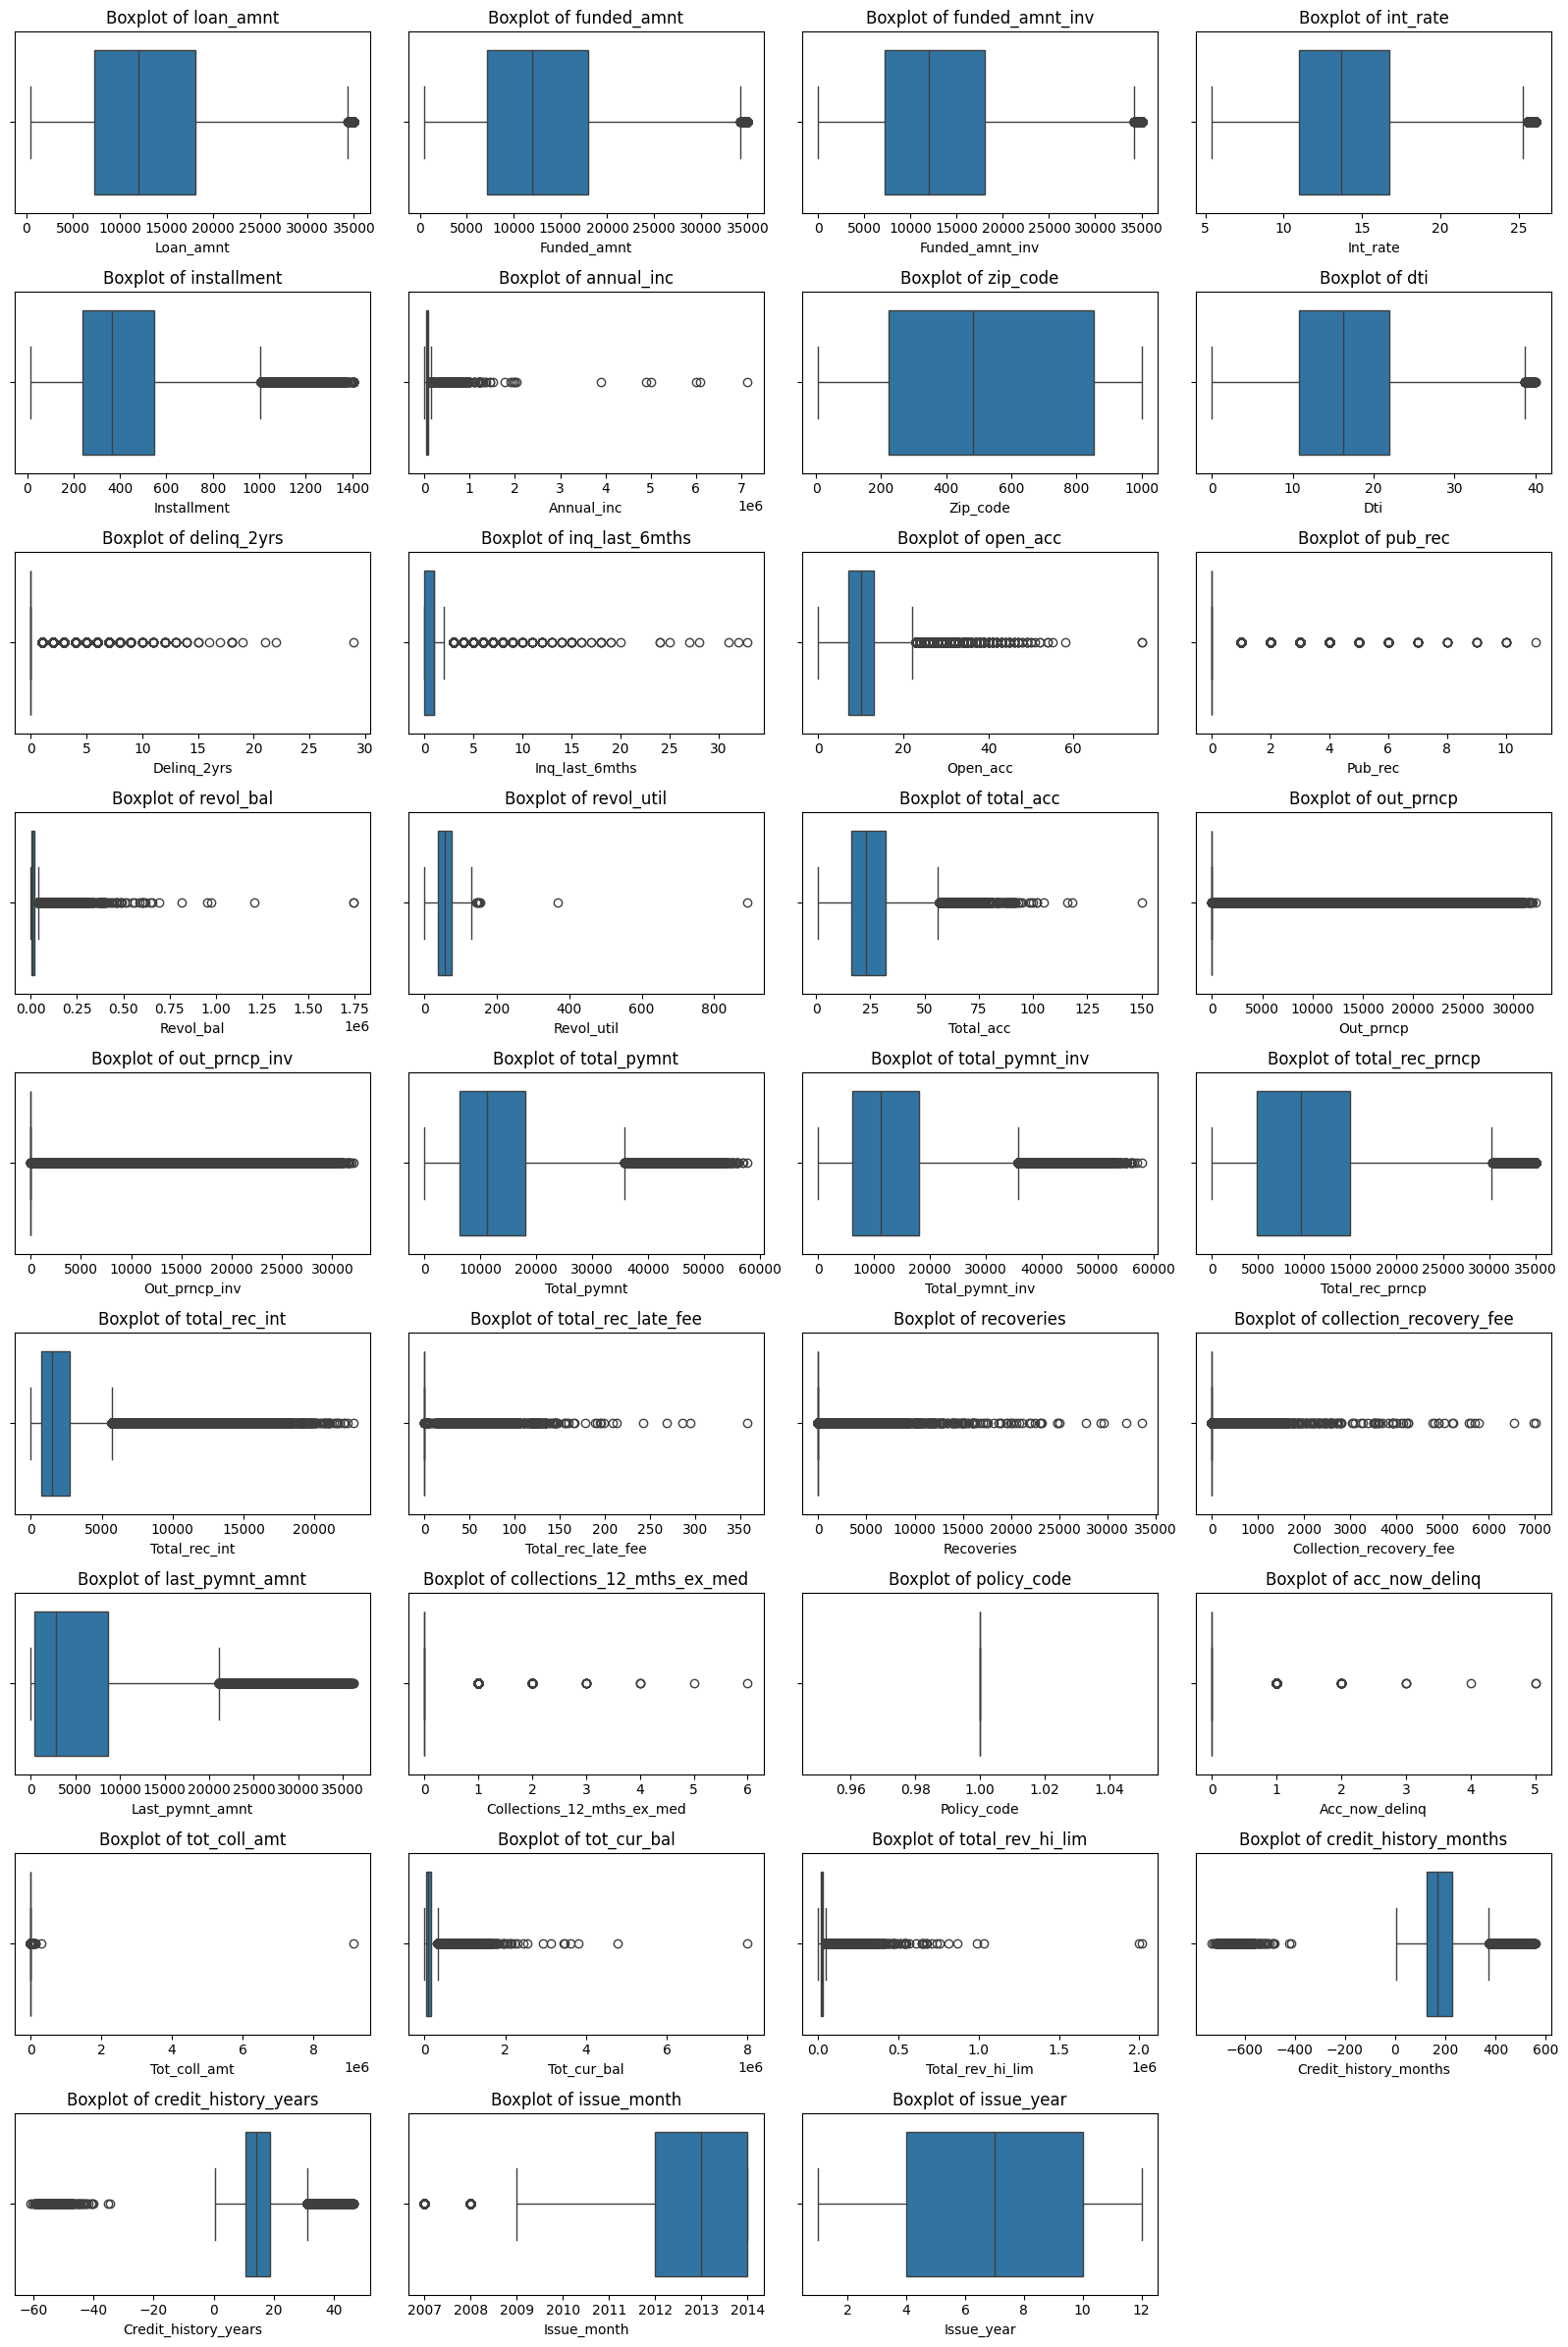

In [21]:
num_cols=Df.select_dtypes(include=['number']).columns
fig, axes=plt.subplots(9,4, figsize=(16,24))
axes=axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=Df, x=col, ax=axes[i])
    axes[i].set_xlabel(f'{col.capitalize()}')
    axes[i].set_title(f'Boxplot of {col}')

fig.delaxes(axes[-1])
plt.tight_layout()
plt.show()

# Data Preparation

## Encode

### Ordinal Encoding

In [22]:
cols = ['loan_status','term','emp_length','verification_status','pymnt_plan']

for c in cols:
    Df[c] = Df[c].astype(str).str.strip()

In [23]:
encode_loan={
    'Bad':1,
    'Good':0
}
encode_term={
    '36 months':0,
    '60 months':1
}
encode_emplenghth={
    '< 1 year':0,
    '1 year':1,
    '2 years':2,
    '3 years':3,
    '4 years':4,
    '5 years':5,
    '6 years':6,
    '7 years':7,
    '8 years':8,
    '9 years':9,
    '10+ years':10,
    'Unknown':11
}
encode_verification={
    'Not Verified':0,
    'Source Verified':1,
    'Verified':2
}
encode_payment={
    'n':0,
    'y':1
}
Df['loan_status']=Df['loan_status'].map(encode_loan)
Df['term']=Df['term'].map(encode_term)
Df['emp_length']=Df['emp_length'].map(encode_emplenghth)
Df['verification_status']=Df['verification_status'].map(encode_verification)
Df['pymnt_plan']=Df['pymnt_plan'].map(encode_payment)

## Label Encoding

In [24]:
col=['title','emp_title']
le=LabelEncoder()
for c in col:
  Df[c]=le.fit_transform(Df[c].astype(str))

## One Hot Encoding

In [25]:
Df=pd.get_dummies(Df, drop_first=True, dtype=int)

### Split Training Data

In [26]:
X=Df.drop(columns='loan_status', axis=1)
y=Df['loan_status']

In [27]:
X_train, X_test, y_train, y_test=train_test_split(X,y, test_size=0.2, random_state=42)
print(f"Training Data Shape X_train:{X_train.shape}, y_train:{y_train.shape}")
print(f"Test Data Shape X_test:{X_test.shape}, y_test:{y_test.shape}")

Training Data Shape X_train:(193647, 143), y_train:(193647,)
Test Data Shape X_test:(48412, 143), y_test:(48412,)


### Balance Variable Target

In [28]:
train_df=X_train.copy()
train_df['loan_status']=y_train

diabetes_majority=train_df[train_df['loan_status']==0]
diabetes_minority=train_df[train_df['loan_status']==1]

diabetes_oversample_minority=resample(
    diabetes_minority,
    replace=True,
    n_samples=len(diabetes_majority),
    random_state=42
)
train_balanced=pd.concat([diabetes_majority,diabetes_oversample_minority])
train_balanced=train_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

X_train=train_balanced.drop(columns='loan_status',axis=1)
y_train=train_balanced['loan_status']
y_train.value_counts()

,count
loan_status,
1,149437
0,149437


# Model

## Logistic Regression

In [29]:
LG=LogisticRegression().fit(X_train, y_train)
eval_lg=LG.predict(X_test)

acc_lg=accuracy_score(y_test, eval_lg)
precision_lg=precision_score(y_test, eval_lg)
recall_lg=recall_score(y_test, eval_lg)
f1_lg=f1_score(y_test, eval_lg)
roc_auc_lg=roc_auc_score(y_test, eval_lg)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
Metrics_df=({
    'Accuracy':[acc_lg],
    'Precision':[precision_lg],
    'Recall':[recall_lg],
    'F1 Score':[f1_lg],
    'ROC AUG':[roc_auc_lg]
})
Metrics_df=pd.DataFrame(Metrics_df, index=['Linear Regression'])
Metrics_df.head()

,Accuracy,Precision,Recall,F1 Score,ROC AUG
Linear Regression,0.99622,0.994306,0.989211,0.991752,0.993761


## Random Forest

In [31]:
RF=RandomForestClassifier().fit(X_train, y_train)
eval_rf=RF.predict(X_test)

acc_rf=accuracy_score(y_test, eval_rf)
precision_rf=precision_score(y_test, eval_rf)
recall_rf=recall_score(y_test, eval_rf)
f1_rf=f1_score(y_test, eval_rf)
roc_auc_rf=roc_auc_score(y_test, eval_rf)

In [32]:
Metrics_df.loc['Random Forest']=[acc_rf, precision_rf, recall_rf, f1_rf, roc_auc_rf]
Metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC AUG
Linear Regression,0.996220,0.994306,0.989211,0.991752,0.993761
Random Forest,0.997397,1.000000,0.988671,0.994303,0.994336


## Decision Tree

In [33]:
DT=DecisionTreeClassifier().fit(X_train, y_train)
eval_dt=DT.predict(X_test)

acc_dt=accuracy_score(y_test, eval_dt)
precision_dt=precision_score(y_test, eval_dt)
recall_dt=recall_score(y_test, eval_dt)
f1_dt=f1_score(y_test, eval_dt)
roc_auc_dt=roc_auc_score(y_test, eval_dt)

In [34]:
Metrics_df.loc['Decision Tree']=[acc_dt, precision_dt, recall_dt, f1_dt, roc_auc_dt]
Metrics_df

,Accuracy,Precision,Recall,F1 Score,ROC AUG
Linear Regression,0.996220,0.994306,0.989211,0.991752,0.993761
Random Forest,0.997397,1.000000,0.988671,0.994303,0.994336
Decision Tree,0.996075,0.991635,0.991279,0.991457,0.994392


## Confusion Matrix Decision Tree

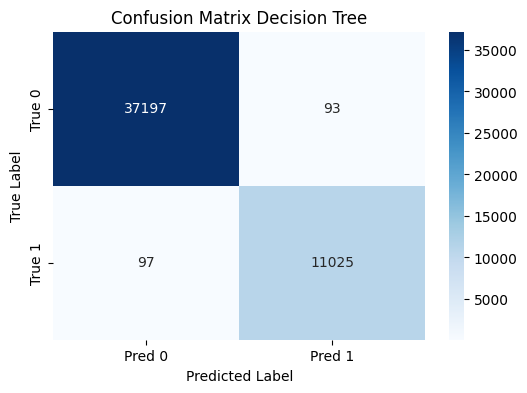

In [36]:
cm_test_dt=confusion_matrix(y_test, eval_dt)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test_dt, annot=True, fmt='d', cmap='Blues', xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Decision Tree')
plt.show()